__1. Construct Decision Tree models for classification and regression applications__

__Data Acquisition and Train-Test Splits for Classification__

In [1]:
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
# Load Pima Indians Diabetes dataset
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [6]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [7]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

In [8]:
X_pima = pima_df[pima_cols[:-1]]

In [9]:
y_pima = pima_df['Outcome']

In [10]:
# Split into 80% train and 20% test partition
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

In [11]:
print("Pima Classification Training Set Shape:", X_train_c.shape)

Pima Classification Training Set Shape: (614, 8)


In [12]:
print("Pima Classification Test Set Shape:", X_test_c.shape)

Pima Classification Test Set Shape: (154, 8)


__Constructing the Decision Tree Classifier__

In [13]:
from sklearn.tree import DecisionTreeClassifier

In [14]:
from sklearn.metrics import accuracy_score, classification_report

In [15]:
# Initialize Decision Tree Classifier with depth regularization
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)

In [16]:
tree_clf.fit(X_train_c, y_train_c)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
# Evaluate performance
clf_preds = tree_clf.predict(X_test_c)

In [18]:
print(f"Decision Tree Classifier Test Accuracy: {accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n")

Decision Tree Classifier Test Accuracy: 79.87%



In [20]:
print("--- Classification Report ---")
print(classification_report(y_test_c, clf_preds, target_names=['No Diabetes (0)', 'Diabetes (1)']))

--- Classification Report ---
                 precision    recall  f1-score   support

No Diabetes (0)       0.82      0.88      0.85       100
   Diabetes (1)       0.74      0.65      0.69        54

       accuracy                           0.80       154
      macro avg       0.78      0.76      0.77       154
   weighted avg       0.80      0.80      0.80       154



__Visualizing the Trained Decision Tree Structure__

In [21]:
import matplotlib.pyplot as plt

In [22]:
from sklearn.tree import plot_tree

In [23]:
# Plot tree structure
plt.figure(figsize=(15, 8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

Text(0.5, 1.0, 'Decision Tree Classifier Structure (Max Depth = 4)')

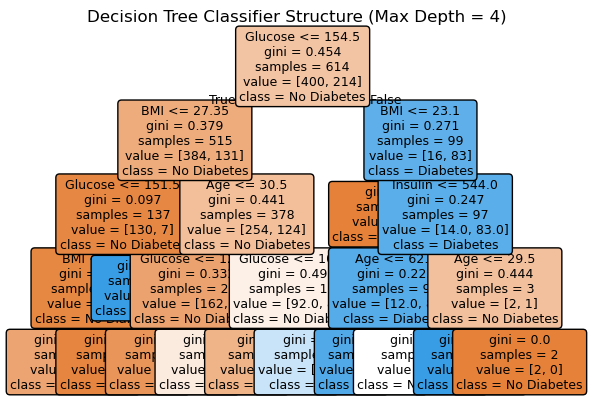

In [26]:
plot_tree(
    tree_clf, 
    feature_names=pima_cols[:-1], 
    class_names=['No Diabetes', 'Diabetes'], 
    filled=True, 
    rounded=True, 
    fontsize=9
)
plt.title("Decision Tree Classifier Structure (Max Depth = 4)")

__Constructing a Decision Tree Regressor__

In [28]:
from sklearn.tree import DecisionTreeRegressor

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
# Load the Boston Housing dataset from public CSV repository
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

In [31]:
boston_df = pd.read_csv(boston_url)

In [32]:
boston_features = [col for col in boston_df.columns if col != 'medv']

In [33]:
X_boston = boston_df[boston_features]

In [34]:
y_boston = boston_df['medv']

In [35]:
# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_boston, y_boston, test_size=0.20, random_state=42)

In [36]:
# Standardize features
scaler_r = StandardScaler()

In [37]:
X_train_r_scaled = scaler_r.fit_transform(X_train_r)

In [38]:
X_test_r_scaled = scaler_r.transform(X_test_r)

In [39]:
# Initialize and train Decision Tree Regressor
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)

In [40]:
tree_reg.fit(X_train_r_scaled, y_train_r)


,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [41]:
print("Decision Tree Regressor trained successfully. Max Depth set to 5.")

Decision Tree Regressor trained successfully. Max Depth set to 5.


__Evaluating Decision Tree Regressor Predictions__

In [42]:
from sklearn.metrics import mean_squared_error, r2_score

In [43]:
import numpy as np

In [44]:
# Predict and compute metrics
reg_preds = tree_reg.predict(X_test_r_scaled)

In [45]:
mse_val = mean_squared_error(y_test_r, reg_preds)

In [46]:
rmse_val = np.sqrt(mse_val)

In [47]:
r2_val = r2_score(y_test_r, reg_preds)

In [48]:
print(f"Mean Squared Error (MSE): {mse_val:.4f}")

Mean Squared Error (MSE): 8.5539


In [49]:
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f} ($1000s)")

Root Mean Squared Error (RMSE): 2.9247 ($1000s)


In [50]:
print(f"R2 Coefficient of Determination: {r2_val:.4f}\n")

R2 Coefficient of Determination: 0.8834



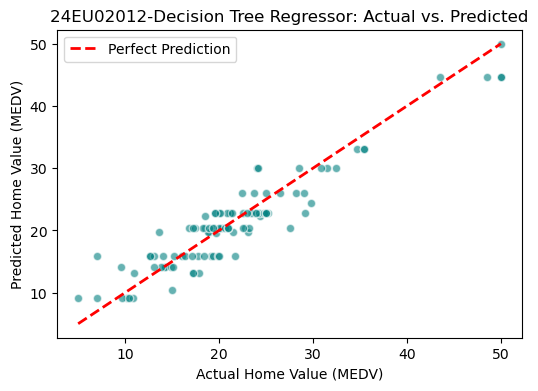

In [60]:
# Plot Actual vs Predicted values
plt.figure(figsize=(6, 4))
plt.scatter(y_test_r, reg_preds, color='teal', alpha=0.6, edgecolor='white')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("24EU02012-Decision Tree Regressor: Actual vs. Predicted")
plt.xlabel("Actual Home Value (MEDV)")
plt.ylabel("Predicted Home Value (MEDV)")
plt.legend()
plt.show()

__2. Develop ensemble learning models using Bagging, Random Forest, and Voting techniques__

__Standard Scaling and High-Dimensional Target Map__

In [61]:
import warnings

In [62]:
warnings.filterwarnings("ignore")

In [63]:
import pandas as pd

In [64]:
from sklearn.model_selection import train_test_split

In [65]:
from sklearn.preprocessing import StandardScaler

In [66]:
# Load Sonar dataset
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [67]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [68]:
sonar_columns = sonar_features + ['Class']

In [69]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [70]:
# Encode class: M -> 1, R -> 0
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [71]:
X_sonar = sonar_df[sonar_features]

In [72]:
y_sonar = sonar_df['Class_numeric']

In [73]:
# Scale features
scaler_sonar = StandardScaler()

In [74]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [75]:
# Split into train/test validation partitions
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

In [76]:
print("Sonar Training Set Shape:", X_train_s.shape)

Sonar Training Set Shape: (145, 60)


In [77]:
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Test Set Shape: (63, 60)


__Implementing a Bagging Classifier__

In [78]:
from sklearn.ensemble import BaggingClassifier

In [79]:
from sklearn.metrics import accuracy_score

In [80]:
# Initialize and train Bagging Classifier
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
bagging_model.fit(X_train_s, y_train_s)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,50
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


In [81]:
# Evaluate accuracy
bagging_preds = bagging_model.predict(X_test_s)

In [82]:
bagging_accuracy = accuracy_score(y_test_s, bagging_preds)

In [83]:
print(f"Bagging Classifier Test Accuracy: {bagging_accuracy * 100:.2f}%")

Bagging Classifier Test Accuracy: 80.95%


__Implementing a Random Forest Classifier__

In [84]:
from sklearn.ensemble import RandomForestClassifier

In [85]:
# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [86]:
rf_model.fit(X_train_s, y_train_s)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [87]:
# Evaluate accuracy
rf_preds = rf_model.predict(X_test_s)

In [88]:
rf_accuracy = accuracy_score(y_test_s, rf_preds)

In [89]:
print(f"Random Forest Classifier Test Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Classifier Test Accuracy: 82.54%


__Implementing a Voting Ensemble Classifier__

In [90]:
from sklearn.ensemble import VotingClassifier

In [91]:
from sklearn.linear_model import LogisticRegression

In [92]:
from sklearn.svm import SVC

In [93]:
# Define base estimators
estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

In [94]:
# Initialize and train soft Voting Classifier
voting_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

In [95]:
voting_model.fit(X_train_s, y_train_s)

,estimators,"[('lr', ...), ('dt', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,-1
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [96]:
# Evaluate accuracy
voting_preds = voting_model.predict(X_test_s)

In [97]:
voting_accuracy = accuracy_score(y_test_s, voting_preds)

In [98]:
print(f"Voting Classifier Test Accuracy: {voting_accuracy * 100:.2f}%")

Voting Classifier Test Accuracy: 87.30%


__Performance Comparison of Ensemble Techniques__

In [99]:
import matplotlib.pyplot as plt

In [100]:
import seaborn as sns

In [101]:
# Compile results
ensemble_results = pd.DataFrame({
    'Ensemble Technique': ['Bagging (DT Base)', 'Random Forest', 'Voting Classifier (Soft)'],
    'Test Accuracy (%)': [bagging_accuracy * 100, rf_accuracy * 100, voting_accuracy * 100]
})

In [102]:
print("--- Performance Comparison ---")
print(ensemble_results.to_string(index=False))

--- Performance Comparison ---
      Ensemble Technique  Test Accuracy (%)
       Bagging (DT Base)          80.952381
           Random Forest          82.539683
Voting Classifier (Soft)          87.301587


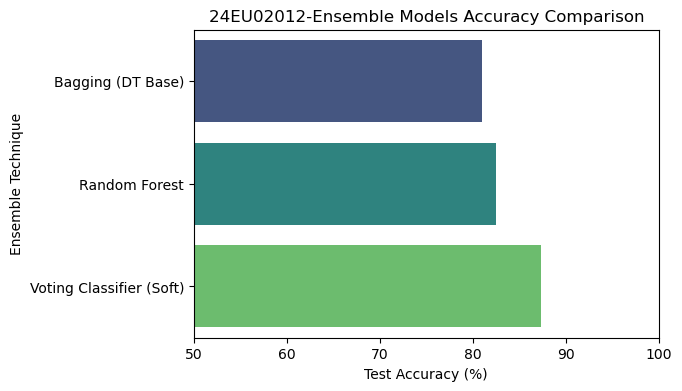

In [104]:
# Plot comparative bar chart
plt.figure(figsize=(6, 4))
sns.barplot(data=ensemble_results, x='Test Accuracy (%)', y='Ensemble Technique', palette='viridis')
plt.xlim([50, 100])
plt.title("24EU02012-Ensemble Models Accuracy Comparison")
plt.show()

__3. Implement and compare boosting techniques including AdaBoost and Gradient Boosting for predictive enhancement__

__Implementing the AdaBoost Classifier__

In [106]:
import warnings

In [107]:
warnings.filterwarnings("ignore")

In [108]:
from sklearn.ensemble import AdaBoostClassifier

In [109]:
from sklearn.metrics import accuracy_score

In [110]:
# Initialize and train AdaBoost Classifier (with default Decision Tree stumps)
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)

In [111]:
adaboost_model.fit(X_train_s, y_train_s)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [112]:
# Evaluate accuracy
ada_preds = adaboost_model.predict(X_test_s)

In [113]:
ada_accuracy = accuracy_score(y_test_s, ada_preds)

In [114]:
print(f"AdaBoost Classifier Test Accuracy: {ada_accuracy * 100:.2f}%")

AdaBoost Classifier Test Accuracy: 85.71%


__Implementing the Gradient Boosting Classifier__

In [116]:
from sklearn.ensemble import GradientBoostingClassifier

In [117]:
# Initialize and train a baseline Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

In [118]:
gb_model.fit(X_train_s, y_train_s)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [119]:
# Evaluate accuracy
gb_preds = gb_model.predict(X_test_s)

In [120]:
gb_accuracy = accuracy_score(y_test_s, gb_preds)

In [121]:
print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy * 100:.2f}%")

Gradient Boosting Classifier Test Accuracy: 80.95%


__Hyperparameter Tuning for Gradient Boosting Classifier__

In [122]:
from sklearn.model_selection import GridSearchCV


In [123]:
# Define parameter grid for Gradient Boosting
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5]
}


In [124]:
# Run Grid Search
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_gb.fit(X_train_s, y_train_s)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [125]:
# Extract optimized model and predict
best_gb = grid_gb.best_estimator_

In [126]:
tuned_gb_preds = best_gb.predict(X_test_s)

In [127]:
tuned_gb_accuracy = accuracy_score(y_test_s, tuned_gb_preds)

In [128]:
print("Optimal Hyperparameters Selected:", grid_search_params := grid_gb.best_params_)

Optimal Hyperparameters Selected: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}


In [129]:
print(f"Tuned Gradient Boosting Test Accuracy: {tuned_gb_accuracy * 100:.2f}%")

Tuned Gradient Boosting Test Accuracy: 79.37%


__Master Comparison: Ensemble vs. Boosting Models__

In [131]:
# Assemble master performance records
master_comparison = pd.DataFrame({
    'Model Classifier': [
        'Bagging Classifier', 
        'Random Forest Classifier', 
        'Voting Ensemble (Soft)', 
        'AdaBoost Classifier', 
        'Base Gradient Boosting', 
        'Tuned Gradient Boosting'
    ],
    'Accuracy (%)': [
        bagging_accuracy * 100, 
        rf_accuracy * 100, 
        voting_accuracy * 100, 
        ada_accuracy * 100, 
        gb_accuracy * 100, 
        tuned_gb_accuracy * 100
    ]
}).sort_values(by='Accuracy (%)', ascending=False)

In [132]:
print("--- Master Performance Table: Tasks 2 & 3 ---")
print(master_comparison.to_string(index=False))

--- Master Performance Table: Tasks 2 & 3 ---
        Model Classifier  Accuracy (%)
  Voting Ensemble (Soft)     87.301587
     AdaBoost Classifier     85.714286
Random Forest Classifier     82.539683
      Bagging Classifier     80.952381
  Base Gradient Boosting     80.952381
 Tuned Gradient Boosting     79.365079


__Plotting Feature Importances (Random Forest vs. Tuned Gradient Boosting)__

In [133]:
import matplotlib.pyplot as plt
import numpy as np

In [134]:
# Extract feature importances
rf_importances = rf_model.feature_importances_
gb_importances = best_gb.feature_importances_

In [135]:
# Isolate top 10 features for both models
top_indices_rf = np.argsort(rf_importances)[-10:]
top_indices_gb = np.argsort(gb_importances)[-10:]

In [136]:
# Define the standard 60-feature names list cleanly
features_list = [f"F_{i}" for i in range(1, 61)]

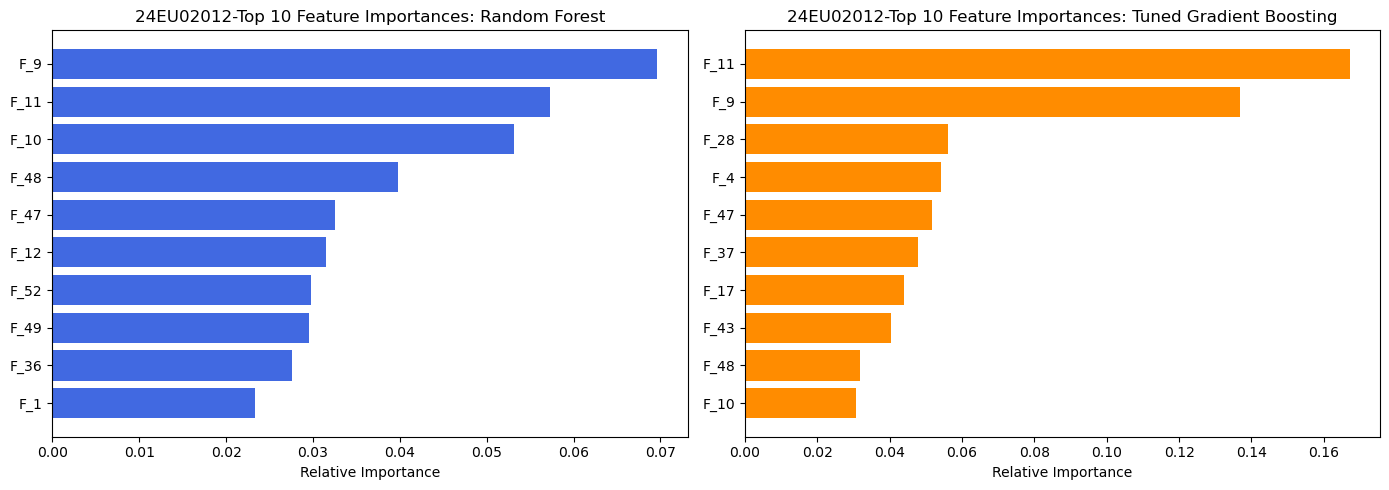

In [141]:
# Set up canvas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot Random Forest Importances
axes[0].barh(range(10), rf_importances[top_indices_rf], color='royalblue', align='center')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([features_list[i] for i in top_indices_rf])
axes[0].set_title("24EU02012-Top 10 Feature Importances: Random Forest")
axes[0].set_xlabel("Relative Importance")
# Plot Tuned Gradient Boosting Importances
axes[1].barh(range(10), gb_importances[top_indices_gb], color='darkorange', align='center')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([features_list[i] for i in top_indices_gb])
axes[1].set_title("24EU02012-Top 10 Feature Importances: Tuned Gradient Boosting")
axes[1].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()